In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
ruta_csv = '/content/drive/My Drive/DATASET/PLN/DATASET_150.csv'
import pandas as pd
df = pd.read_csv(ruta_csv, encoding='utf-8')

df.head()

,id,url,text,source,created_at,author_username,author_name,author_location,author_created,author_favourites_count,author_media_count,author_statuses_count,place_country,place_full_name,place_name,place_id,place_place_type,place_coordinates,lon,lat
0,1000082083853713409,https://x.com/HeyJC_/status/1000082083853713409,Yo ya ni me esfuerzo en hacerlo porque luego p...,Twitter for Android,25/05/2018 13:32,HeyJC_,Juan Carlos⚡️,"Querétaro Arteaga, México",23/03/2012 20:43,23463,509,9506.0,Mexico,"Querétaro, Querétaro Arteaga",Querétaro,d3492c68c5661201,city,"POLYGON((-100.5963431 20.5031701, -100.5963431...",-100.440595,20.715275
1,1000166664892174336,https://x.com/MuErTe_ChIqUiTa/status/100016666...,"@fernandac710 Además, ya obligaron a los demás...",Twitter for iPhone,25/05/2018 19:08,MuErTe_ChIqUiTa,MuErTe cHiQuItA,México,05/09/2009 19:13,5091,169,3539.0,Mexico,"Benito Juárez, Distrito Federal",Benito Juárez,7d93122509633720,city,"POLYGON((-99.1919955 19.357102, -99.1919955 19...",-99.161480,19.380613
2,1000178687793336320,https://x.com/Rosalinda_F_H/status/10001786877...,L@s invito a que nos sumemos al #DiaNaranja. ...,Twitter for iPhone,25/05/2018 19:55,Rosalinda_F_H,Rosalinda Figueroa,"Santa María Huatulco, Oaxaca",19/04/2010 12:18,12904,228,15016.0,Mexico,"San Pedro Pochutla, Oaxaca",San Pedro Pochutla,f6aa0dce95d47c0d,city,"POLYGON((-96.531534 15.6574918, -96.531534 15....",-96.396036,15.789067
3,1000185709586731008,https://x.com/ashitakasalto/status/10001857095...,@Tania_Tagle Una vez estaba en una playa nudis...,Twitter for Android,25/05/2018 20:23,ashitakasalto,Ashitaka,NaN,04/06/2012 14:39,124710,4022,78240.0,Mexico,Mexico,Mexico,25530ba03b7d90c6,country,"POLYGON((-118.4038571 14.5319181, -118.4038571...",-102.558037,23.625419
4,1000205783001387008,https://x.com/MuErTe_ChIqUiTa/status/100020578...,"@garobiela @fernandac710 Son tan básicos, que ...",Twitter for iPhone,25/05/2018 21:43,MuErTe_ChIqUiTa,MuErTe cHiQuItA,México,05/09/2009 19:13,5091,169,3539.0,Mexico,"Benito Juárez, Distrito Federal",Benito Juárez,7d93122509633720,city,"POLYGON((-99.1919955 19.357102, -99.1919955 19...",-99.161480,19.380613


In [3]:
textos = df['text'].dropna().astype(str)

import re

def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r"http\S+|www\S+|https\S+", '', texto)
    texto = re.sub(r"\@w+|\#", '', texto)
    texto = re.sub(r"[^a-záéíóúüñ ]", '', texto)
    texto = re.sub(r"\s+", ' ', texto).strip()
    return texto

textos_limpios = textos.apply(limpiar_texto)


In [4]:
from sklearn.feature_extraction.text import CountVectorizer
import nltk
from nltk.corpus import stopwords

try:
    stopwords_es = stopwords.words('spanish')
except LookupError:
    nltk.download('stopwords')
    stopwords_es = stopwords.words('spanish')

stopwords_extra = stopwords_es + [
    'de', 'que', 'la', 'en', 'y', 'a', 'me', 'no', 'el', 'un', 'solo', 'va', 'hacer', 'sé',
    'te', 'tu', 'lo', 'si', 'por', 'para', 'jajaja', 'jajajajaja', 'jaja', 'pues', 'hoy', 'ma', 'mi', 'del',
    'jajajaja', 'día', 'días', 'ser', 'soy', 'es', 'los', 'las', 'q', 'voy', 'así', 'da', 'k', 'xq', 'dio', 'como'
]


vectorizer = CountVectorizer(max_df=0.9, min_df=5, stop_words=stopwords_es)
X = vectorizer.fit_transform(textos_limpios)

print("Matriz de términos creada con forma:", X.shape)

Matriz de términos creada con forma: (151813, 29248)


In [5]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X)

LatentDirichletAllocation(n_components=5, random_state=42)

In [6]:
def mostrar_top_palabras(modelo, vectorizer, n_palabras=10):
    palabras = vectorizer.get_feature_names_out()
    for idx, topic in enumerate(modelo.components_):
        print(f"Tópico {idx+1}:")
        print(" ".join([palabras[i] for i in topic.argsort()[:-n_palabras - 1:-1]]))
        print()

mostrar_top_palabras(lda, vectorizer)

Tópico 1:
acoso jajaja bullying sexual mujeres hoy así jajajajaja violencia servicio

Tópico 2:
día días hoy vida buenos buen semana excelente siempre gracias

Tópico 3:
si lopezobrador así pues mejor claudiashein méxico solo presidente ser

Tópico 4:
si bien gracias acoso gente solo ser ver va así

Tópico 5:
jajajaja foto amén mexico madre acaba dios publicar ahora buenas



In [7]:
palabras = vectorizer.get_feature_names_out()
print(palabras)

['aa' 'aaa' 'aaaa' ... 'útero' 'útil' 'útiles']


In [8]:
diccionario = vectorizer.vocabulary_
print(diccionario)

{'esfuerzo': 10301, 'hacerlo': 12824, 'luego': 16494, 'piensan': 21126, 'acoso': 346, 'jajaj': 14666, 'además': 496, 'obligaron': 19372, 'demás': 7826, 'residentes': 23756, 'elaborar': 9295, 'carta': 4497, 'niegan': 19049, 'laboral': 15436, 'ls': 16455, 'invito': 14460, 'niñas': 19099, 'mujeres': 18555, 'méxico': 18692, 'mundo': 18578, 'derecho': 7927, 'vida': 28373, 'libre': 15960, 'violencia': 28496, 'únete': 29239, 'días': 9068, 'cada': 3906, 'mes': 17694, 'naranja': 18796, 'taniatagle': 26379, 'vez': 28287, 'playa': 21354, 'zona': 29122, 'gay': 12108, 'chava': 4941, 'mas': 17288, 'feliz': 11202, 'nunca': 19309, 'rodeada': 24191, 'hombres': 13217, 'jugando': 15136, 'sola': 25615, 'olas': 19612, 'mar': 17028, 'pesada': 21022, 'carga': 4368, 'ahí': 877, 'di': 8335, 'cuenta': 7080, 'chavas': 4943, 'hetero': 13078, 'buscan': 3803, 'espacios': 10313, 'tan': 26371, 'básicos': 3838, 'seguramente': 24964, 'así': 2431, 'debe': 7498, 'ser': 25116, 'evidencia': 10657, 'si': 25285, 'pasas': 203

In [9]:
print(f"Número de palabras en el diccionario: {len(palabras)}")

Número de palabras en el diccionario: 29248


In [10]:
!pip install gensim

In [11]:
import gensim
from gensim import corpora
import nltk
from nltk.corpus import stopwords

# Descargar stopwords en español si no lo has hecho
nltk.download('stopwords')
stopwords_es = stopwords.words('spanish')

# Stopwords extra detectadas en tus resultados
stopwords_extra = [
    'de', 'que', 'la', 'en', 'y', 'a', 'me', 'no', 'el', 'un', 'te', 'tu', 'aa' 'aaa' 'aaaa', 'solo', 'va', 'hacer', 'sé',
    'te', 'tu', 'lo', 'si', 'por', 'para', 'gracias', 'jajaja', 'jajajajaja', 'jaja', 'pues', 'hoy',
    'lo', 'si', 'por', 'para', 'gracias', 'jajaja', 'jajajaja', 'día', 'días', 'va', 'hacer', 'sé',
    'ser', 'soy', 'es', 'mi', 'del', 'las', 'los', 'eres', 'los', 'las', 'q', 'voy', 'así', 'da', 'k', 'xq'
]

# Combina todas las stopwords
stopwords_final = set(stopwords_es + stopwords_extra)

# Tokeniza y elimina stopwords
textos_tokenizados = [
    [palabra for palabra in t.split() if palabra not in stopwords_final]
    for t in textos_limpios
]

# Crear diccionario y corpus
dictionary = corpora.Dictionary(textos_tokenizados)
dictionary.filter_extremes(no_below=5, no_above=0.9)
corpus = [dictionary.doc2bow(texto) for texto in textos_tokenizados]

# Entrenar modelo LDA
lda_model = gensim.models.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=5,
    random_state=42
)

# Ver temas
temas = lda_model.print_topics()
for i, tema in temas:
    print(f"Tema {i}: {tema}")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Tema 0: 0.011*"amén" + 0.011*"feliz" + 0.010*"hermosa" + 0.010*"excelente" + 0.010*"claudiashein" + 0.009*"buenos" + 0.009*"hola" + 0.007*"semana" + 0.006*"undíacomohoy" + 0.005*"año"
Tema 1: 0.009*"año" + 0.008*"bien" + 0.008*"solo" + 0.008*"bullying" + 0.007*"siempre" + 0.007*"mejor" + 0.007*"vida" + 0.007*"hace" + 0.007*"hoy" + 0.006*"ver"
Tema 2: 0.011*"méxico" + 0.006*"acoso" + 0.006*"buenas" + 0.006*"gobierno" + 0.005*"presidente" + 0.005*"lopezobrador" + 0.005*"país" + 0.005*"morena" + 0.004*"noches" + 0.004*"poder"
Tema 3: 0.033*"acoso" + 0.009*"sexual" + 0.007*"mujeres" + 0.006*"bullying" + 0.005*"parte" + 0.005*"personas" + 0.004*"violencia" + 0.004*"hoy" + 0.003*"lunes" + 0.003*"nueva"
Tema 4: 0.007*"san" + 0.007*"dios" + 0.006*"saludos" + 0.005*"buen" + 0.005*"mexico" + 0.005*"méxico" + 0.005*"salud" + 0.005*"nació" + 0.004*"felicidades" + 0.004*"nuevo"


In [12]:
!pip install pyLDAvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 35.4 MB/s eta 0:00:00


In [13]:
import pyLDAvis
import pyLDAvis.gensim_models

pyLDAvis.enable_notebook()

# Preparar visualización
panel = pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary)
panel

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1      0.051464 -0.103206       1        1  29.093382
2      0.100257  0.091394       2        1  21.026902
3      0.237808  0.110327       3        1  18.863198
0     -0.096198 -0.299216       4        1  16.050712
4     -0.293330  0.200702       5        1  14.965806, topic_info=           Term         Freq        Total Category  logprob  loglift
0         acoso  8985.000000  8985.000000  Default  30.0000  30.0000
9578       amén  2037.000000  2037.000000  Default  29.0000  29.0000
36        feliz  2046.000000  2046.000000  Default  28.0000  28.0000
851     hermosa  1866.000000  1866.000000  Default  27.0000  27.0000
1554  excelente  1937.000000  1937.000000  Default  26.0000  26.0000
...         ...          ...          ...      ...      ...      ...
22       méxico   845.237234  4393.618330   Topic5  -5.3117   0.2511
1165    familia   506.363938  1183.957000   Topic5  -5.8240   1.0500
684        bien   485.220155  3882.184682   Topic5  -5.8667  -0.1801
662      muchas   425.260667  1173.484380   Topic5  -5.9986   0.8844
1841       gran   406.372849  1470.129378   Topic5  -6.0440   0.6136

[325 rows x 6 columns], token_table=      Topic      Freq       Term
term                            
4356      4  0.999444     abrazo
2631      2  0.999447   acapulco
3738      3  0.997781  accidente
0         1  0.018585      acoso
0         2  0.169043      acoso
...     ...       ...        ...
7638      1  0.998887     última
2046      1  0.944932     último
2046      2  0.044281     último
2046      3  0.003163     último
2046      5  0.007907     último

[636 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 3, 4, 1, 5])

In [14]:
assert len(df) == len(textos_limpios), "Número de filas no coincide con textos_limpios"
assert len(df) == len(textos_tokenizados), "Número de filas no coincide con textos_tokenizados"

# Asignar columnas al DataFrame original
df['text_cleaned'] = textos_limpios
df['tokens'] = textos_tokenizados

# Verificar resultado
df[['text', 'text_cleaned', 'tokens']].head()

,text,text_cleaned,tokens
0,Yo ya ni me esfuerzo en hacerlo porque luego p...,yo ya ni me esfuerzo en hacerlo porque luego p...,"[esfuerzo, hacerlo, luego, piensan, acoso, jajaj]"
1,"@fernandac710 Además, ya obligaron a los demás...",fernandac además ya obligaron a los demás resi...,"[fernandac, además, obligaron, demás, resident..."
2,L@s invito a que nos sumemos al #DiaNaranja. ...,ls invito a que nos sumemos al dianaranja las ...,"[ls, invito, sumemos, dianaranja, niñas, mujer..."
3,@Tania_Tagle Una vez estaba en una playa nudis...,taniatagle una vez estaba en una playa nudista...,"[taniatagle, vez, playa, nudista, zona, gay, c..."
4,"@garobiela @fernandac710 Son tan básicos, que ...",garobiela fernandac son tan básicos que segura...,"[garobiela, fernandac, tan, básicos, seguramen..."


In [15]:
df.to_csv('/content/drive/My Drive/DATASET/PLN/DATASET_150_PREPROCESADO.csv', index=False, encoding='utf-8')

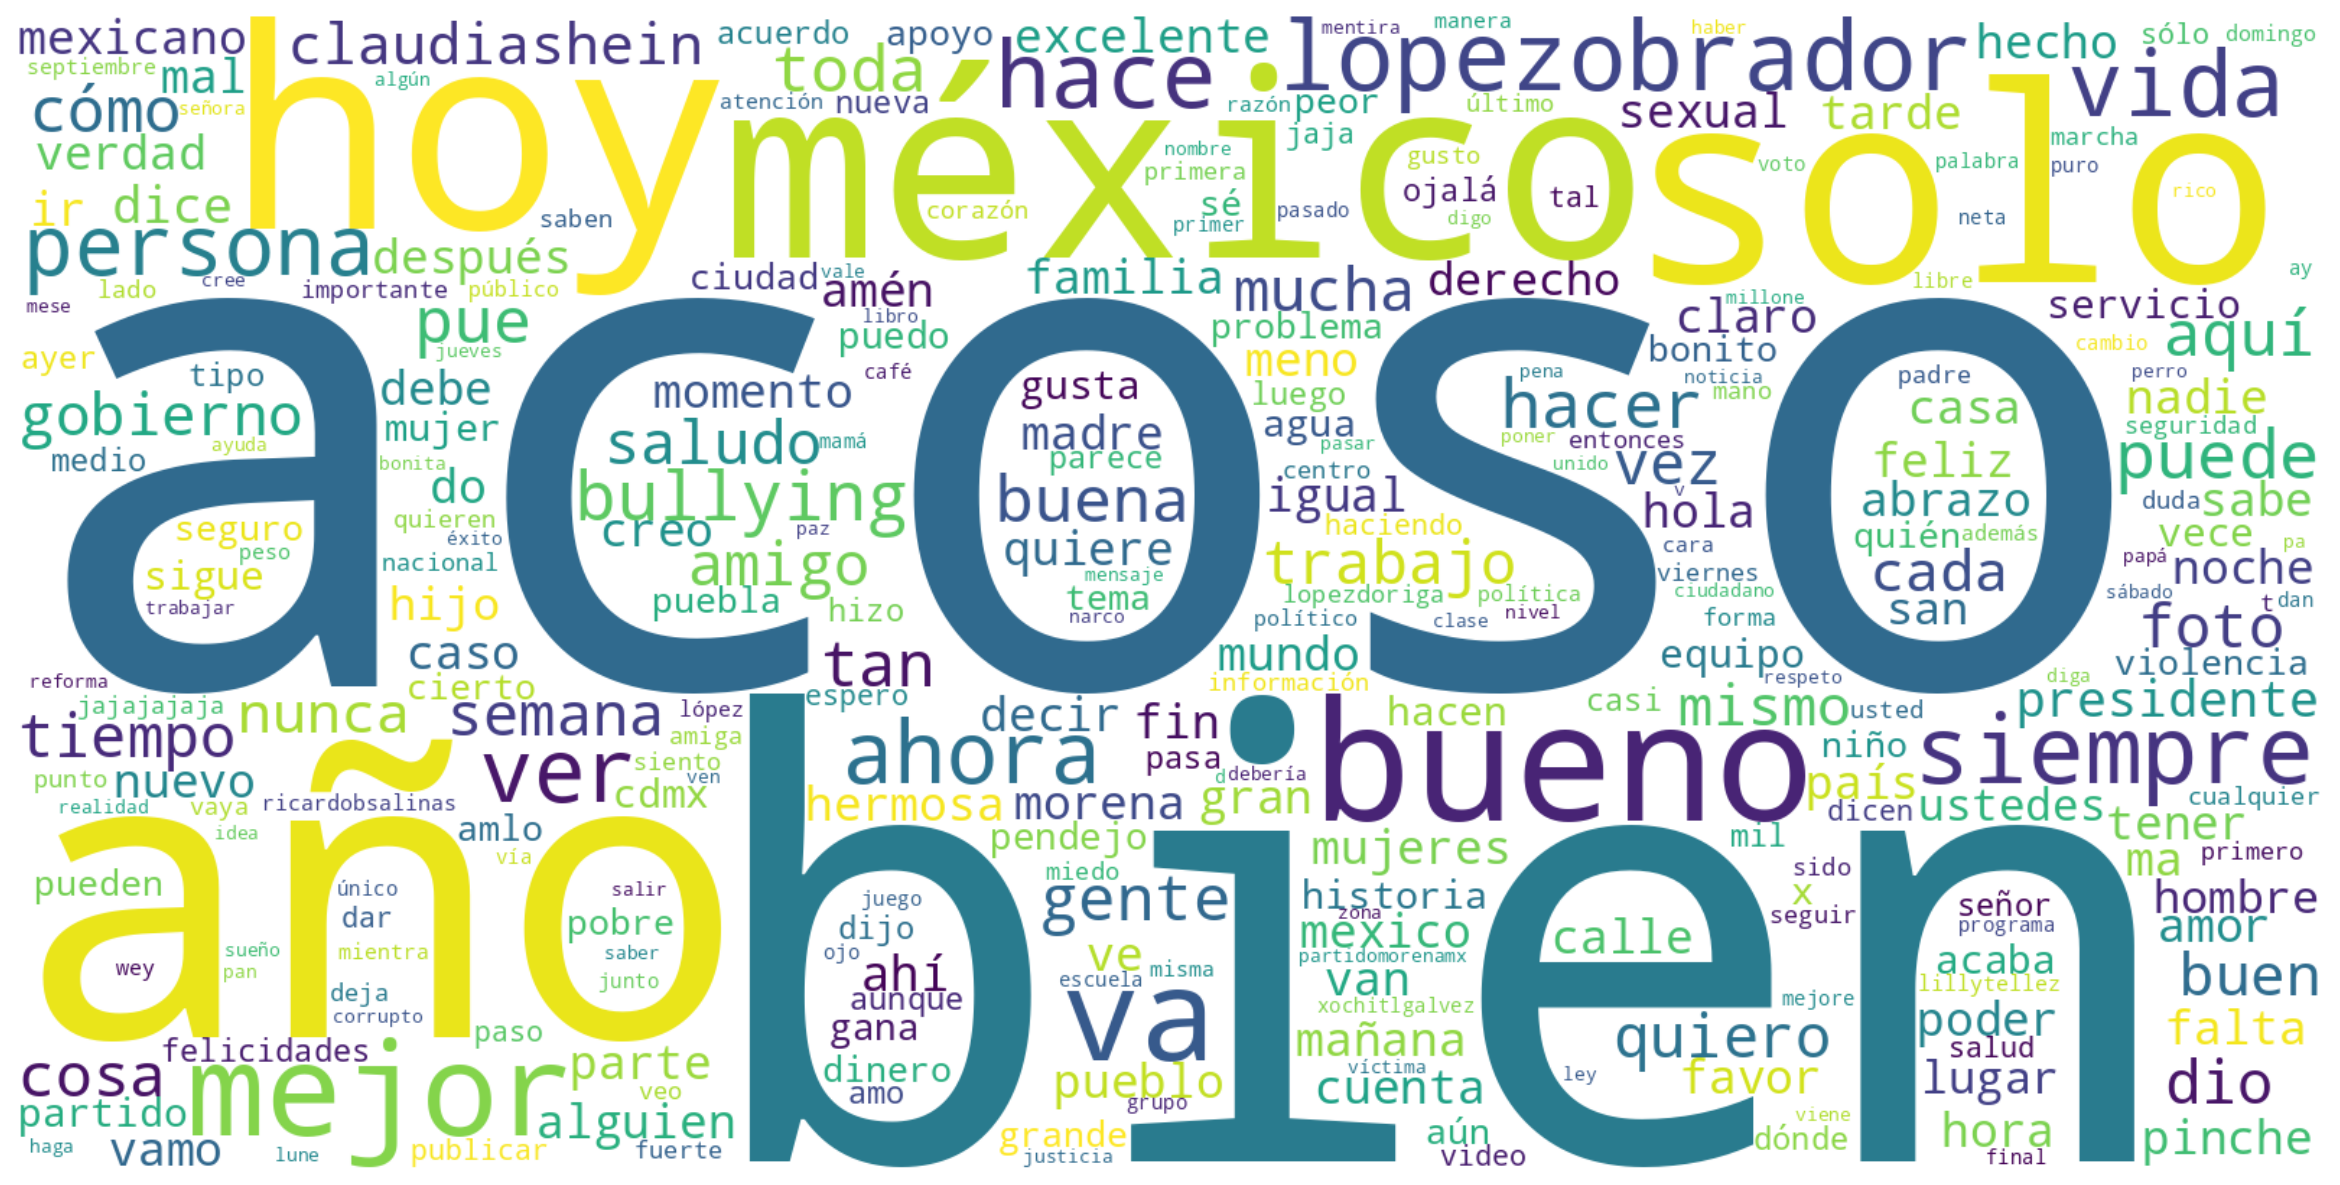

In [17]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Texto combinado
texto_filtrado = ' '.join(df["text_cleaned"].dropna())

# Nube de palabras de alta resolución
wordcloud = WordCloud(
    width=1600,              # Aumenta el ancho
    height=800,              # Aumenta el alto
    background_color='white',
    stopwords=stopwords_final,
    max_words=300,           # Limita a las 300 palabras más frecuentes
    contour_width=0.5,       # Borde suave
    contour_color='black',
    collocations=False,      # Evita combinaciones de palabras redundantes
    prefer_horizontal=1.0    # Mayor preferencia por palabras horizontales
).generate(texto_filtrado)

# Mostrar imagen con mayor DPI
plt.figure(figsize=(16, 8), dpi=150)  # Mayor resolución al mostrar
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.tight_layout()
plt.show()
